# Hierarchical Screening Record

This notebook preserves the hierarchical screening workflow used to predict oxidation potential, donor number, ESPmin, and ESPmax, followed by ESPratio filtering, molecular fingerprinting, t-SNE projection, and K-means cluster assignment. Source text, comments, and inline messages are standardized in English, while historical execution outputs are retained as the run record.


#### 1. Oxidation potential prediction

In [8]:
from unimol_tools import MolTrain, MolPredict
import numpy as np
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from pathlib import Path

# Resolve paths relative to the repository root.
PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / 'data'
SCREENING_DIR = PROJECT_ROOT / 'outputs' / 'hierarchical_screening'
TRAINING_DIR = PROJECT_ROOT / 'outputs' / 'unimol_training'

def screening_file(*parts):
    path = SCREENING_DIR.joinpath(*parts)
    path.parent.mkdir(parents=True, exist_ok=True)
    return str(path)

def screening_dir(*parts):
    path = SCREENING_DIR.joinpath(*parts)
    path.mkdir(parents=True, exist_ok=True)
    return str(path)

def training_dir(*parts):
    return str(TRAINING_DIR.joinpath(*parts))


# Load the trained predictor
clf = MolPredict(load_model = training_dir('Result', 'Oxidation Potential'))

# SMILES
smiles_file_path = str(DATA_DIR / 'pubchem_cleaned_data.csv')
# Run prediction
predict_op = clf.predict(data = smiles_file_path)

# Read the original SMILES data
smiles_df = pd.read_csv(smiles_file_path)
predict_op = predict_op.flatten()

# Create a result DataFrame containing SMILES and predicted values
results_smiles_df = pd.DataFrame({
    'SMILES': smiles_df['SMILES'],  # Assumes the SMILES column is named'SMILES'
    'Predicted Oxidation Potential': predict_op
})


# Save prediction results
output_smiles_path = screening_file('Oxidation_Potential', 'predict_op.csv')
results_smiles_df.to_csv(output_smiles_path, index=False)

print(f"Prediction completed. Results saved to: {output_smiles_path}")
print(f"Predicted {len(predict_op)} molecules")

2025-06-15 11:17:28 | unimol_tools/data/conformer.py | 446 | INFO | Uni-Mol Tools | Start generating conformers...
37613it [02:33, 244.34it/s]
2025-06-15 11:20:02 | unimol_tools/data/conformer.py | 461 | INFO | Uni-Mol Tools | Succeeded in generating conformers for 99.99% of molecules.
2025-06-15 11:20:02 | unimol_tools/data/conformer.py | 470 | INFO | Uni-Mol Tools | Failed conformers indices: [4677, 5539, 13081]
2025-06-15 11:20:02 | unimol_tools/data/conformer.py | 478 | INFO | Uni-Mol Tools | Succeeded in generating 3d conformers for 99.63% of molecules.
2025-06-15 11:20:02 | unimol_tools/data/conformer.py | 487 | INFO | Uni-Mol Tools | Failed 3d conformers indices: [6, 8, 11, 13, 22, 23, 25, 26, 27, 28, 32, 129, 1075, 1079, 1697, 1704, 1838, 1970, 2223, 2253, 2254, 2260, 2275, 2417, 2731, 2775, 2845, 2927, 3094, 3172, 3173, 3176, 3223, 3230, 3237, 3239, 3258, 3297, 3315, 3318, 3354, 3394, 3452, 3458, 3523, 3564, 3641, 3690, 3696, 3829, 3831, 3897, 3922, 4031, 4072, 4151, 4152, 421

预测完成！结果已保存到: /home/hank/code/unimol_tools/dataset/to_predict/Oxidation Potential/predict_op.csv
共预测了 37613 个分子


#### 1.1 Filter molecules with predicted oxidation potential above 4.0 V

In [5]:
import pandas as pd

# Read the CSV file
file_path = screening_file('Oxidation_Potential', 'predict_op.csv')
df = pd.read_csv(file_path)

# 
print(":")
print(f": {len(df)}")
print(f": {list(df.columns)}")
print("\n5:")
print(df.head())

# 2.64
high_op_molecules = df[df['Predicted Oxidation Potential'] > 4]

# 
print(f"\n4: {len(high_op_molecules)}")
print("\n:")
print(high_op_molecules)

# 
output_path = screening_file('Oxidation_Potential', 'high_op_molecules.csv')
high_op_molecules.to_csv(output_path, index=False)
print(f"\n: {output_path}")

# 
print(f"\n:")
print(f": {df['Predicted Oxidation Potential'].min():.3f}")
print(f": {df['Predicted Oxidation Potential'].max():.3f}")
print(f": {df['Predicted Oxidation Potential'].mean():.3f}")
print(f": {df['Predicted Oxidation Potential'].median():.3f}")

# SMILES
print(f"\n>4SMILES:")
smiles_list = high_op_molecules['SMILES'].tolist()
for i, smiles in enumerate(smiles_list, 1):
    print(f"{i}. {smiles}")

数据集基本信息:
总分子数: 1020122
列名: ['SMILES', 'Predicted Oxidation Potential']

前5行数据:
                          SMILES  Predicted Oxidation Potential
0   CC(C)(C)C(C)(C)O[SiH2][SiH3]                       1.990141
1     CCOC(CS(=O)(=O)CCC(C)C)OCC                       2.287837
2                       CN(Cl)Br                       1.965794
3       CCCCCCC(=O)C.CCCCC(=O)CC                       1.762314
4  CC(C)(C)C(CCl)C1CCS(=O)(=O)C1                       2.526148

预测氧化电位大于4的分子数量: 5182

符合条件的分子:
                                 SMILES  Predicted Oxidation Potential
18          C(F)(F)F.C(C(F)(F)F)(F)(F)F                       4.313905
34                     C[Si](C)(CBr)C#N                       4.034979
299                     C1C(=O)OC(=O)O1                       4.189519
784      C(C(C(C(F)(F)F)(F)F)(F)F)(F)Cl                       4.192694
1074                             [Si]Cl                       4.272387
...                                 ...                            ...
1018519 

#### 2. Donor number prediction

In [6]:
from unimol_tools import MolTrain, MolPredict

# Load the trained predictor
clf_dn = MolPredict(load_model = training_dir('Result', 'Donor Number', 'fold_5', 'final'))

# Path to the SMILES-only dataset
smiles_only_file_path = rscreening_file('Oxidation_Potential', 'high_op_molecules.csv')
# Run prediction
predict_smiles_only = clf_dn.predict(data = smiles_only_file_path)

# Read the original SMILES data
smiles_df = pd.read_csv(smiles_only_file_path)
predict_values_smiles_only = predict_smiles_only.flatten()

# Create a result DataFrame containing SMILES and predicted values
results_smiles_df = pd.DataFrame({
    'SMILES': smiles_df['SMILES'],  # Assumes the SMILES column is named'SMILES'
    'Donor Number': predict_values_smiles_only
})


# Save prediction results
output_smiles_path = screening_file('Donor_number', 'predict_dn.csv')
results_smiles_df.to_csv(output_smiles_path, index=False)

print(f"Prediction completed. Results saved to: {output_smiles_path}")
print(f"Predicted {len(predict_values_smiles_only)} molecules")

2025-09-01 15:08:01 | unimol_tools/data/conformer.py | 171 | INFO | Uni-Mol Tools | Start generating conformers...
5182it [00:02, 1918.78it/s]
2025-09-01 15:08:04 | unimol_tools/data/conformer.py | 187 | INFO | Uni-Mol Tools | Succeeded in generating conformers for 99.81% of molecules.
2025-09-01 15:08:04 | unimol_tools/data/conformer.py | 196 | INFO | Uni-Mol Tools | Failed conformers indices: [387, 1048, 1147, 1792, 2015, 3197, 3811, 3986, 4858, 5035]
2025-09-01 15:08:04 | unimol_tools/data/conformer.py | 205 | INFO | Uni-Mol Tools | Succeeded in generating 3d conformers for 93.63% of molecules.
2025-09-01 15:08:04 | unimol_tools/data/conformer.py | 214 | INFO | Uni-Mol Tools | Failed 3d conformers indices: [4, 20, 37, 48, 84, 96, 98, 140, 180, 253, 258, 275, 296, 315, 350, 357, 377, 382, 387, 389, 391, 398, 413, 428, 445, 448, 467, 468, 473, 519, 525, 562, 584, 592, 602, 607, 635, 643, 644, 648, 665, 686, 754, 792, 808, 821, 832, 833, 876, 909, 927, 937, 943, 951, 961, 1009, 1015, 1

预测完成！结果已保存到: /home/hank/code/unimol_tools/dataset/to_predict/Donor number/predict_dn.csv
共预测了 5182 个分子


#### 2.1 Filter molecules with predicted DN above 10 kcal mol-1

In [11]:
import pandas as pd

# Read the CSV file
file_path = screening_file('Donor_number', 'predict_dn.csv')
df = pd.read_csv(file_path)

# 
print(":")
print(f": {len(df)}")
print(f": {list(df.columns)}")
print("\n5:")
print(df.head())

# 2.64
high_dn_molecules = df[df['Donor Number'] > 10]

# 
print(f"\nDN10: {len(high_dn_molecules)}")
print("\n:")
print(high_dn_molecules)

# 
output_path = screening_file('Donor_number', 'high_dn_molecules.csv')
high_dn_molecules.to_csv(output_path, index=False)
print(f"\n: {output_path}")

# DN
print(f"\nDN:")
print(f": {df['Donor Number'].min():.3f}")
print(f": {df['Donor Number'].max():.3f}")
print(f": {df['Donor Number'].mean():.3f}")
print(f": {df['Donor Number'].median():.3f}")

# SMILES
print(f"\nDN>10SMILES:")
smiles_list = high_dn_molecules['SMILES'].tolist()
for i, smiles in enumerate(smiles_list, 1):
    print(f"{i}. {smiles}")

数据集基本信息:
总分子数: 5182
列名: ['SMILES', 'Donor Number']

前5行数据:
                           SMILES  Donor Number
0     C(F)(F)F.C(C(F)(F)F)(F)(F)F      4.293885
1                C[Si](C)(CBr)C#N     22.458702
2                 C1C(=O)OC(=O)O1     10.585183
3  C(C(C(C(F)(F)F)(F)F)(F)F)(F)Cl      1.727998
4                          [Si]Cl     10.873450

预测DN值大于10的分子数量: 1468

符合条件的分子:
                            SMILES  Donor Number
1                 C[Si](C)(CBr)C#N     22.458702
2                  C1C(=O)OC(=O)O1     10.585183
4                           [Si]Cl     10.873450
7                CCC#N.CCC#N.CCC#N     19.513323
14                C(F)(F)(F)[SiH3]     10.375210
...                            ...           ...
5168                       CCC.N#N     34.657322
5173             C(C#N)OC(=O)SCC#N     18.097740
5176                O.F[Si](F)(F)F     12.227604
5177  C(CC(C(F)(F)F)(F)F)C(C#N)C#N     10.323482
5179                     F[Si][Si]     11.499556

[1468 rows x 2 columns]

结果已保存到:

#### 2.2 Additional DN prediction for reviewer-response audit data

In [ ]:
from unimol_tools import MolTrain, MolPredict
import numpy as np
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Load the trained predictor
clf_dn_response = MolPredict(load_model = training_dir('Result', 'Donor Number', 'fold_5', 'final'))

# SMILES
smiles_file_path = screening_file('angew_response', 'pred_dn.csv')
# Run prediction
predict_dn_response = clf_dn_response.predict(data = smiles_file_path)

# Read the original SMILES data
smiles_df = pd.read_csv(smiles_file_path)
predict_dn_response = predict_dn_response.flatten()

# Create a result DataFrame containing SMILES and predicted values
results_smiles_df = pd.DataFrame({
    'SMILES': smiles_df['SMILES'],  # Assumes the SMILES column is named'SMILES'
    'Predicted DN Response': predict_dn_response
})


# Save prediction results
output_smiles_path = screening_file('angew_response', 'pred_dn_result.csv')
results_smiles_df.to_csv(output_smiles_path, index=False)

# print(f"Prediction completed. Results saved to: {output_smiles_path}")
# print(f"Predicted {len(predict_op)} molecules")

2026-04-21 13:58:29 | unimol_tools/data/conformer.py | 171 | INFO | Uni-Mol Tools | Start generating conformers...
45it [00:00, 879.55it/s]
2026-04-21 13:58:29 | unimol_tools/data/conformer.py | 187 | INFO | Uni-Mol Tools | Succeeded in generating conformers for 100.00% of molecules.
2026-04-21 13:58:29 | unimol_tools/data/conformer.py | 205 | INFO | Uni-Mol Tools | Succeeded in generating 3d conformers for 100.00% of molecules.
2026-04-21 13:58:29 | unimol_tools/data/datahub.py | 185 | INFO | Uni-Mol Tools | conf_cache_level is 1, saving conformers to /home/hank/code/unimol_tools/Result/Donor Number/fold_5/final/pred_dn.sdf.
2026-04-21 13:58:29 | unimol_tools/data/datahub.py | 199 | INFO | Uni-Mol Tools | Successfully saved sdf file to /home/hank/code/unimol_tools/Result/Donor Number/fold_5/final/pred_dn.sdf
2026-04-21 13:58:29 | unimol_tools/tasks/trainer.py | 78 | INFO | Uni-Mol Tools | Number of GPUs available: 1
2026-04-21 13:58:29 | unimol_tools/tasks/trainer.py | 98 | INFO | Uni

预测完成！结果已保存到: /home/hank/code/unimol_tools/dataset/to_predict/angew_response/pred_dn_result.csv


NameError: name 'predict_op' is not defined

#### 3. ESPmin prediction

In [14]:
from unimol_tools import MolTrain, MolPredict

# Load the trained predictor
clf_espmin = MolPredict(load_model = training_dir('Result', 'ESP', 'single_target', 'espmin', 'final'))

# 
smiles_only_file_path = screening_file('Donor_number', 'high_dn_molecules.csv')
# Run prediction
predict_espmin = clf_espmin.predict(data = smiles_only_file_path)

# Read the original SMILES data
smiles_df = pd.read_csv(smiles_only_file_path)
predict_espmin = predict_espmin.flatten()

# Create a result DataFrame containing SMILES and predicted values
results_smiles_df = pd.DataFrame({
    'SMILES': smiles_df['SMILES'],  # Assumes the SMILES column is named'SMILES'
    'ESPmin': predict_espmin
})


# Save prediction results
output_smiles_path = screening_file('ESPmin', 'predict_espmin.csv')
results_smiles_df.to_csv(output_smiles_path, index=False)

print(f"Prediction completed. Results saved to: {output_smiles_path}")
print(f"Predicted {len(smiles_df)} molecules")

2025-09-01 15:22:35 | unimol_tools/data/conformer.py | 171 | INFO | Uni-Mol Tools | Start generating conformers...
1468it [00:01, 1351.91it/s]
2025-09-01 15:22:37 | unimol_tools/data/conformer.py | 187 | INFO | Uni-Mol Tools | Succeeded in generating conformers for 99.32% of molecules.
2025-09-01 15:22:37 | unimol_tools/data/conformer.py | 196 | INFO | Uni-Mol Tools | Failed conformers indices: [111, 294, 329, 500, 554, 883, 1059, 1111, 1372, 1428]
2025-09-01 15:22:37 | unimol_tools/data/conformer.py | 205 | INFO | Uni-Mol Tools | Succeeded in generating 3d conformers for 81.88% of molecules.
2025-09-01 15:22:37 | unimol_tools/data/conformer.py | 214 | INFO | Uni-Mol Tools | Failed 3d conformers indices: [2, 6, 11, 29, 36, 37, 57, 79, 82, 91, 102, 108, 109, 111, 112, 118, 121, 129, 133, 134, 144, 149, 160, 169, 172, 174, 180, 182, 186, 191, 206, 218, 225, 230, 233, 234, 243, 254, 260, 264, 267, 270, 274, 284, 294, 303, 320, 322, 324, 325, 329, 339, 346, 349, 361, 365, 373, 375, 381, 38

预测完成！结果已保存到: /home/hank/code/unimol_tools/dataset/to_predict/ESPmin/predict_espmin.csv
共预测了 1468 个分子


#### 4. ESPmax prediction

In [15]:
from unimol_tools import MolTrain, MolPredict

# Load the trained predictor
clf_espmax = MolPredict(load_model = training_dir('Result', 'ESP', 'single_target', 'espmax', 'final'))

# Path to the SMILES-only dataset
smiles_only_file_path = screening_file('Donor_number', 'high_dn_molecules.csv')
# Run prediction
predict_smiles_only = clf_espmax.predict(data = smiles_only_file_path)

# Read the original SMILES data
smiles_df = pd.read_csv(smiles_only_file_path)
predict_values_smiles_only = predict_smiles_only.flatten()

# Create a result DataFrame containing SMILES and predicted values
results_smiles_df = pd.DataFrame({
    'SMILES': smiles_df['SMILES'],  # Assumes the SMILES column is named'SMILES'
    'ESPmax': predict_values_smiles_only
})


# Save prediction results
output_smiles_path = screening_file('ESPmax', 'predict_espmax.csv')
results_smiles_df.to_csv(output_smiles_path, index=False)

print(f"Prediction completed. Results saved to: {output_smiles_path}")
print(f"Predicted {len(smiles_df)} molecules")

2025-09-01 15:22:58 | unimol_tools/data/conformer.py | 171 | INFO | Uni-Mol Tools | Start generating conformers...
1468it [00:01, 1372.10it/s]
2025-09-01 15:23:00 | unimol_tools/data/conformer.py | 187 | INFO | Uni-Mol Tools | Succeeded in generating conformers for 99.32% of molecules.
2025-09-01 15:23:00 | unimol_tools/data/conformer.py | 196 | INFO | Uni-Mol Tools | Failed conformers indices: [111, 294, 329, 500, 554, 883, 1059, 1111, 1372, 1428]
2025-09-01 15:23:00 | unimol_tools/data/conformer.py | 205 | INFO | Uni-Mol Tools | Succeeded in generating 3d conformers for 81.88% of molecules.
2025-09-01 15:23:00 | unimol_tools/data/conformer.py | 214 | INFO | Uni-Mol Tools | Failed 3d conformers indices: [2, 6, 11, 29, 36, 37, 57, 79, 82, 91, 102, 108, 109, 111, 112, 118, 121, 129, 133, 134, 144, 149, 160, 169, 172, 174, 180, 182, 186, 191, 206, 218, 225, 230, 233, 234, 243, 254, 260, 264, 267, 270, 274, 284, 294, 303, 320, 322, 324, 325, 329, 339, 346, 349, 361, 365, 373, 375, 381, 38

预测完成！结果已保存到: /home/hank/code/unimol_tools/dataset/to_predict/ESPmax/predict_espmax.csv
共预测了 1468 个分子


#### 5. Merge ESPmin and ESPmax predictions and calculate ESPratio

In [16]:
import pandas as pd
import os
import numpy as np

# 
espmin_df = pd.read_csv(screening_file('ESPmin', 'predict_espmin.csv'))
espmax_df = pd.read_csv(screening_file('ESPmax', 'predict_espmax.csv'))

# SMILES
merged_df = pd.merge(espmin_df, espmax_df, on='SMILES', how='inner')

# |ESPmin/ESPmax|
merged_df['ESPminESPmax'] = np.abs(merged_df['ESPmin'] / merged_df['ESPmax'])

# （）
output_dir = screening_dir('ESP')
os.makedirs(output_dir, exist_ok=True)

# 
merged_df.to_csv(screening_file('ESP', 'predict_esp.csv'), index=False)

print(f"！")
print(f"ESPmin: {espmin_df.shape}")
print(f"ESPmax: {espmax_df.shape}")
print(f": {merged_df.shape}")
print(f": {list(merged_df.columns)}")

# 
print("\n5:")
print(merged_df.head())

数据合并完成！
ESPmin数据集形状: (1468, 2)
ESPmax数据集形状: (1468, 2)
合并后数据集形状: (1468, 4)
合并后的列名: ['SMILES', 'ESPmin', 'ESPmax', 'ESPminESPmax']

合并后数据的前5行:
              SMILES    ESPmin    ESPmax  ESPminESPmax
0   C[Si](C)(CBr)C#N -2.040928  1.631240      1.251152
1    C1C(=O)OC(=O)O1 -1.801073  2.281712      0.789352
2             [Si]Cl -0.906353  2.031421      0.446167
3  CCC#N.CCC#N.CCC#N -2.018743  1.469678      1.373595
4   C(F)(F)(F)[SiH3] -0.814597  1.985094      0.410357


#### 6. Candidate identification using Morgan fingerprints, t-SNE, and K-means regions

In [19]:
# Morgan
import numpy as np
import pandas as pd
import os
from pathlib import Path
from datetime import datetime
from rdkit import Chem
from rdkit.Chem import AllChem


class MolecularFingerprintCalculator:
    """"""
    
    def __init__(self, input_path, smiles_column='SMILES', n_bits=2048, radius=2):
        """
        
        
        Args:
            input_path: CSV
            smiles_column: SMILES，'SMILES'
            n_bits: ，2048
            radius: Morgan，2
        """
        self.input_path = Path(input_path)
        self.smiles_column = smiles_column
        self.n_bits = n_bits
        self.radius = radius
        
        # cache
        script_dir = Path(__file__).parent if '__file__' in globals() else Path.cwd()
        self.output_dir = script_dir.parent / 'cache'
        self.output_dir.mkdir(parents=True, exist_ok=True)
        
        # 
        timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
        base_name = self.input_path.stem
        self.output_filename = f"{base_name}_morgan_fp_{timestamp}"
        
    def calculate_fingerprints(self, smiles_list):
        """Morgan"""
        fingerprints = []
        valid_indices = []
        
        for idx, smiles in enumerate(smiles_list):
            mol = Chem.MolFromSmiles(smiles)
            if mol is not None:
                fp = AllChem.GetMorganFingerprintAsBitVect(mol, self.radius, nBits=self.n_bits)
                fingerprints.append(np.array(fp))
                valid_indices.append(idx)
            else:
                print(f": SMILES ( {idx}): {smiles}")
        
        print(f" {len(fingerprints)}/{len(smiles_list)} molecules")
        return np.array(fingerprints), valid_indices
    
    def run(self):
        """"""
        # 
        df = pd.read_csv(self.input_path)
        print(f": {len(df)} ")
        
        # SMILES
        smiles_list = df[self.smiles_column].tolist()
        fingerprints, valid_indices = self.calculate_fingerprints(smiles_list)
        
        # 
        df_valid = df.iloc[valid_indices].reset_index(drop=True)
        
        # 
        npy_path = self.output_dir / f"{self.output_filename}.npy"
        np.save(npy_path, fingerprints)
        print(f": {npy_path}")
        
        # 
        result_df = df_valid.copy()
        fp_df = pd.DataFrame(fingerprints, columns=[f'fp_{i}' for i in range(self.n_bits)])
        result_df = pd.concat([result_df, fp_df], axis=1)
        
        csv_path = self.output_dir / f"{self.output_filename}.csv"
        result_df.to_csv(csv_path, index=False)
        print(f": {csv_path}")
        
        return fingerprints, df_valid


# 
if __name__ == "__main__":
    # 
    calculator = MolecularFingerprintCalculator(
        input_path=screening_file('ESP', 'predict_esp.csv'),  # Read the CSV file
        smiles_column='SMILES',  # SMILES
        n_bits=2048,  # 
        radius=2  # Morgan
    )
    
    # 
    fingerprints, df = calculator.run()
    
    print(f"\n: {fingerprints.shape}")


加载数据: 1468 行
成功计算 1468/1468 个分子指纹
指纹数组已保存: /home/hank/code/cache/predict_esp_morgan_fp_20250901_153844.npy
完整数据已保存: /home/hank/code/cache/predict_esp_morgan_fp_20250901_153844.csv

指纹矩阵形状: (1468, 2048)


t-SNE降维处理 (小数据集优化版)
加载数据: /home/hank/code/cache/predict_esp_morgan_fp_20250901_153844.csv
数据形状: (1468, 2052)
找到 2048 个指纹特征列
指纹矩阵形状: (1468, 2048)
自动设置perplexity为 50 (基于 1468 个样本)

开始t-SNE降维...
样本数量: 1468
参数设置:
  - n_components: 2
  - perplexity: 50
  - metric: euclidean
  - init: pca
  - learning_rate: auto
  - n_iter: 1500
t-SNE降维完成，KL散度: 1.0770
降维结果形状: (1468, 2)

结果已保存: /home/hank/code/cache/predict_esp_morgan_fp_20250901_153844_tsne_20250901_154125.csv

统计信息:
  tsne_0: min=-51.1569, max=52.9955, mean=0.8470, std=26.1009
  tsne_1: min=-29.4932, max=33.1583, mean=0.3810, std=13.8989

生成可视化...
图像已保存: /home/hank/code/cache/predict_esp_morgan_fp_20250901_153844_tsne_20250901_154125_plot.png


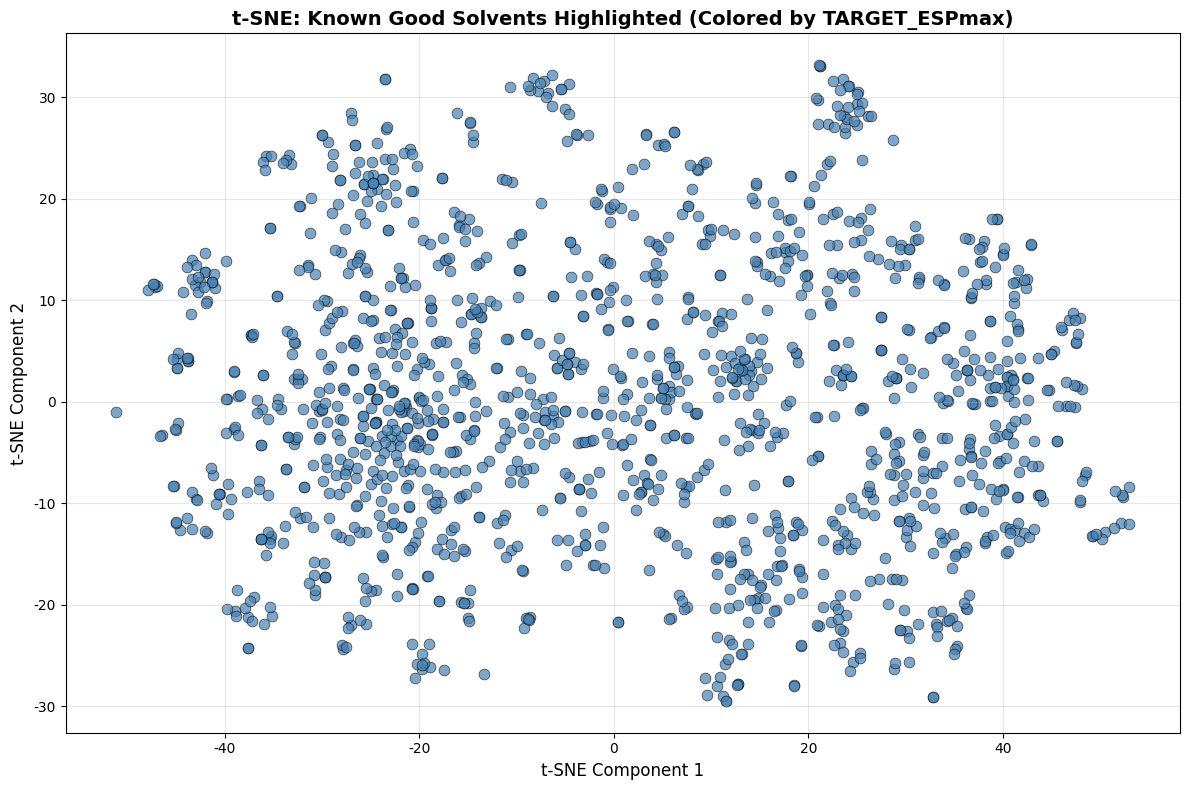


处理完成！


In [ ]:
# 
import numpy as np
import pandas as pd
from pathlib import Path
from datetime import datetime
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.colors import Normalize
import warnings
warnings.filterwarnings('ignore')

# 
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False


class TSNEDimensionalityReducer:
    """t-SNE（）"""
    
    def __init__(self, input_path, n_components=2, perplexity=None, metric='euclidean',
                 init='pca', random_state=42, n_iter=1500, learning_rate='auto',
                 early_exaggeration=12.0):
        """
        t-SNE（）
        
        Args:
            input_path: CSV（Morgan）
            n_components: ，2
            perplexity: t-SNE，None
            metric: ，'euclidean'
            init: ，'pca'（）
            random_state: ，42
            n_iter: ，1500
            learning_rate: ，'auto'
            early_exaggeration: early exaggeration，12.0
        """
        self.input_path = Path(input_path)
        self.n_components = n_components
        self.metric = metric
        self.init = init
        self.random_state = random_state
        self.n_iter = n_iter
        self.learning_rate = learning_rate
        self.early_exaggeration = early_exaggeration
        
        # perplexity
        self.perplexity = perplexity
        self.auto_perplexity = perplexity is None
        
        # 
        script_dir = Path(__file__).parent if '__file__' in globals() else Path.cwd()
        self.output_dir = script_dir.parent / 'cache'
        self.output_dir.mkdir(parents=True, exist_ok=True)
        
        # 
        timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
        base_name = self.input_path.stem
        self.output_filename = f"{base_name}_tsne_{timestamp}"
        
        # 
        self.df = None
        self.X_tsne = None
        
    def extract_fingerprints(self, df):
        """DataFrame"""
        fp_columns = [col for col in df.columns if col.startswith('fp_')]
        
        if not fp_columns:
            raise ValueError("（fp_）")
        
        print(f" {len(fp_columns)} ")
        return df[fp_columns].values, fp_columns
    
    def optimize_perplexity(self, n_samples):
        """perplexity"""
        if self.auto_perplexity:
            # ，perplexity5n/3
            suggested_perplexity = min(max(5, n_samples // 15), 50)
            self.perplexity = suggested_perplexity
            print(f"perplexity {self.perplexity} ( {n_samples} )")
        else:
            # perplexity
            max_perplexity = (n_samples - 1) / 3
            if self.perplexity > max_perplexity:
                print(f": perplexity={self.perplexity} ， {max_perplexity:.0f}")
    
    def perform_tsne(self, fingerprints):
        """t-SNE"""
        n_samples = fingerprints.shape[0]
        self.optimize_perplexity(n_samples)
        
        print(f"\nt-SNE...")
        print(f": {n_samples}")
        print(f":")
        print(f"  - n_components: {self.n_components}")
        print(f"  - perplexity: {self.perplexity}")
        print(f"  - metric: {self.metric}")
        print(f"  - init: {self.init}")
        print(f"  - learning_rate: {self.learning_rate}")
        print(f"  - n_iter: {self.n_iter}")
        
        # t-SNE
        tsne = TSNE(
            n_components=self.n_components,
            perplexity=self.perplexity,
            metric=self.metric,
            init=self.init,
            random_state=self.random_state,
            n_iter=self.n_iter,
            learning_rate=self.learning_rate,
            early_exaggeration=self.early_exaggeration
        )
        
        # 
        X_tsne = tsne.fit_transform(fingerprints)
        
        print(f"t-SNE，KL: {tsne.kl_divergence_:.4f}")
        return X_tsne
    
    def visualize(self, color_column=None, highlight_indices=None, 
                  highlight_labels=None, figsize=(10, 8), save_plot=True,
                  title=None, show_colorbar=True, point_size=50, alpha=0.7):
        """
        t-SNE
        
        Args:
            color_column: （）
            highlight_indices: 
            highlight_labels: （）
            figsize: 
            save_plot: 
            title: 
            show_colorbar: 
            point_size: 
            alpha: 
        """
        if self.X_tsne is None or self.df is None:
            raise ValueError(" run() ")
        
        fig, ax = plt.subplots(1, 1, figsize=figsize)
        
        # 
        if color_column and color_column in self.df.columns:
            # 
            color_values = self.df[color_column].values
            
            # NaN
            valid_mask = ~pd.isna(color_values)
            
            # 
            scatter = ax.scatter(
                self.X_tsne[valid_mask, 0], 
                self.X_tsne[valid_mask, 1],
                c=color_values[valid_mask], 
                cmap='viridis',
                s=point_size, 
                alpha=alpha,
                edgecolors='black', 
                linewidth=0.5
            )
            
            # NaN（）
            if not valid_mask.all():
                ax.scatter(
                    self.X_tsne[~valid_mask, 0], 
                    self.X_tsne[~valid_mask, 1],
                    c='gray', 
                    s=point_size, 
                    alpha=alpha/2,
                    edgecolors='black', 
                    linewidth=0.5,
                    label='NaN values'
                )
            
            if show_colorbar:
                cbar = plt.colorbar(scatter, ax=ax)
                cbar.set_label(color_column, rotation=270, labelpad=20)
            
            if not title:
                title = f't-SNE Visualization (colored by {color_column})'
        else:
            # 
            ax.scatter(
                self.X_tsne[:, 0], 
                self.X_tsne[:, 1],
                c='steelblue', 
                s=point_size, 
                alpha=alpha,
                edgecolors='black', 
                linewidth=0.5
            )
            if not title:
                title = 't-SNE Visualization'
        
        # 
        if highlight_indices is not None:
            highlight_indices = np.array(highlight_indices)
            
            # 
            valid_highlights = highlight_indices[highlight_indices < len(self.X_tsne)]
            
            if len(valid_highlights) > 0:
                # 
                ax.scatter(
                    self.X_tsne[valid_highlights, 0],
                    self.X_tsne[valid_highlights, 1],
                    c='red',
                    s=point_size*2,
                    alpha=1,
                    edgecolors='darkred',
                    linewidth=2,
                    marker='*',
                    label='Highlighted samples',
                    zorder=5
                )
                
                # （）
                if highlight_labels is not None:
                    for idx, label_idx in enumerate(valid_highlights):
                        if idx < len(highlight_labels):
                            ax.annotate(
                                highlight_labels[idx],
                                (self.X_tsne[label_idx, 0], self.X_tsne[label_idx, 1]),
                                xytext=(5, 5),
                                textcoords='offset points',
                                fontsize=8,
                                bbox=dict(boxstyle='round,pad=0.3', 
                                         facecolor='yellow', 
                                         alpha=0.7),
                                arrowprops=dict(arrowstyle='->', 
                                              connectionstyle='arc3,rad=0')
                            )
        
        ax.set_xlabel('t-SNE Component 1', fontsize=12)
        ax.set_ylabel('t-SNE Component 2', fontsize=12)
        ax.set_title(title, fontsize=14, fontweight='bold')
        ax.grid(True, alpha=0.3)
        
        if highlight_indices is not None and len(valid_highlights) > 0:
            ax.legend()
        
        plt.tight_layout()
        
        # 
        if save_plot:
            plot_path = self.output_dir / f"{self.output_filename}_plot.png"
            plt.savefig(plot_path, dpi=150, bbox_inches='tight')
            print(f": {plot_path}")
        
        plt.show()
        
        return fig, ax
    
    def run(self, visualize=True, **viz_kwargs):
        """
        t-SNE
        
        Args:
            visualize: 
            **viz_kwargs: visualize
        """
        print(f"="*50)
        print(f"t-SNE ()")
        print(f"="*50)
        
        # 
        print(f": {self.input_path}")
        self.df = pd.read_csv(self.input_path)
        print(f": {self.df.shape}")
        
        # 
        fingerprints, fp_columns = self.extract_fingerprints(self.df)
        print(f": {fingerprints.shape}")
        
        # t-SNE
        self.X_tsne = self.perform_tsne(fingerprints)
        print(f": {self.X_tsne.shape}")
        
        # DataFrame
        result_df = self.df.drop(columns=fp_columns).copy()
        
        # t-SNE
        for i in range(self.n_components):
            result_df[f'tsne_{i}'] = self.X_tsne[:, i]
        
        # 
        output_path = self.output_dir / f"{self.output_filename}.csv"
        result_df.to_csv(output_path, index=False)
        print(f"\n: {output_path}")
        
        # 
        print(f"\n:")
        for i in range(self.n_components):
            col_name = f'tsne_{i}'
            print(f"  {col_name}: min={result_df[col_name].min():.4f}, "
                  f"max={result_df[col_name].max():.4f}, "
                  f"mean={result_df[col_name].mean():.4f}, "
                  f"std={result_df[col_name].std():.4f}")
        
        # 
        if visualize:
            print(f"\n...")
            self.visualize(**viz_kwargs)
        
        return result_df, self.X_tsne
    


# 
if __name__ == "__main__":

    # 1：Known Good Solvents
    csv_path = screening_file('fingerprints', 'predict_esp_morgan_fp.csv')

    # 2：t-SNE
    reducer = TSNEDimensionalityReducer(
        input_path=csv_path,
        perplexity=None,
        metric='euclidean',
        init='pca',
        n_iter=1500,
        learning_rate='auto'
    )
    
    # 3：
    result_df, X_tsne = reducer.run(
        visualize=True,
        color_column='TARGET_ESPmax',  # TARGET_ESPmax
        point_size=60,
        alpha=0.7,
        title='t-SNE: Known Good Solvents Highlighted (Colored by TARGET_ESPmax)'
    )
    
    # 2：
    # result_df, X_tsne = reducer.run(
    #     visualize=True,
    #     color_column='activity',  # activity
    #     highlight_indices=[0, 50, 100, 200, 300],  # 1, 51, 101, 201, 301
    #     highlight_labels=['A', 'B', 'C', 'D', 'E'],  # 
    #     point_size=60,  # 
    #     alpha=0.8  # 
    # )
    
    # 3：（）
    # reducer.visualize(
    #     color_column='another_column',
    #     highlight_indices=[10, 20, 30],
    #     title='Custom Visualization',
    #     save_plot=True
    # )
    
    print(f"\n！")

K-means New Sample Prediction
Target clusters: C[0, 2, 4]
ESP range: (0.9, 2.4)
Loading model and boundaries...
  K-means model loaded (K=5)
  t-SNE columns used: ['tsne_0', 'tsne_1']
  Voronoi boundaries loaded

Processing new samples: /home/hank/code/cache/predict_esp_morgan_fp_20250901_153844_tsne_20250901_154125.csv
  Number of samples: 1468

Filtering results:
  Samples in target clusters: 1020
  Samples in ESP range: 400
  Candidate molecules: 353

Searching for known molecules...
  Found BN: 1 sample(s)
  Found PN: 1 sample(s)
  Found AN: 1 sample(s)
Total known molecules found: 3

Cluster prediction plot saved: k-mean_predict_plots/cluster_predictions_20251105_102551.tif


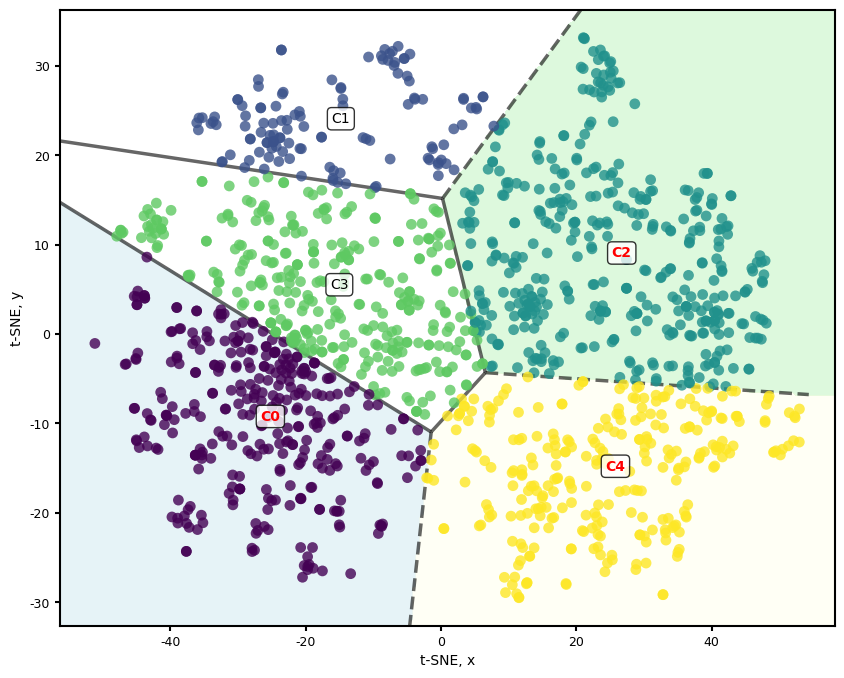


Searching for known molecules...
  Found BN: 1 sample(s)
  Found PN: 1 sample(s)
  Found AN: 1 sample(s)
Total known molecules found: 3

ESP distribution plot saved: k-mean_predict_plots/esp_distribution_20251105_102551.tif


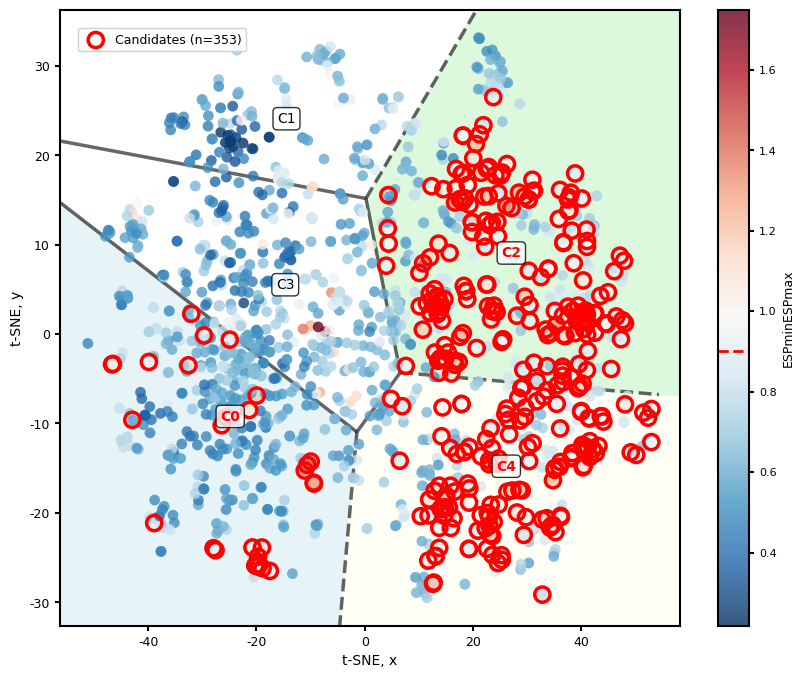


Candidate molecules saved: dataset/to_predict/kmean_model/candidates_20251105_102552.csv
  Total candidates: 353

Candidate molecule cluster distribution:
  C0: 28 molecules
  C2: 192 molecules
  C4: 133 molecules

ESP value statistics:
  Min: 0.900
  Max: 1.620
  Mean: 1.051
  Std: 0.130

Prediction completed!


In [12]:
import numpy as np
import pandas as pd
from pathlib import Path
import pickle
import json
import matplotlib.pyplot as plt
from scipy.spatial import Voronoi, voronoi_plot_2d
from matplotlib.patches import Polygon
from matplotlib.collections import PatchCollection
import warnings
warnings.filterwarnings('ignore')

# Set matplotlib parameters for better display
plt.rcParams['font.sans-serif'] = ['DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False


class KMeansPredictor:
    """K-means predictor for new sample clustering assignment"""
    
    def __init__(self, model_path, voronoi_path, target_clusters=[0, 2, 4], 
                 esp_range=(0.9, 2.4)):
        """
        Initialize predictor
        
        Args:
            model_path: K-means model file path
            voronoi_path: Voronoi boundary file path
            target_clusters: Target cluster list (default C0, C2, C4)
            esp_range: ESPminESPmax range
        """
        self.model_path = Path(model_path)
        self.voronoi_path = Path(voronoi_path)
        self.target_clusters = target_clusters
        self.esp_range = esp_range
        
        # Load model and boundaries
        self.model_data = None
        self.voronoi_data = None
        self.kmeans = None
        self.tsne_columns = None
        
        # Output directory
        self.output_dir = self.model_path.parent
        
        # Define known molecules with their SMILES
        self.known_molecules = {
            'TMP': 'COP(=O)(OC)OC',
            'BN': 'CCCC#N',
            'PN': 'CCC#N',
            'AN': 'CC#N',
            'EMC': 'CCOC(=O)OC',
            'DEC': 'CCOC(=O)OCC',
            'DMC': 'COC(=O)OC',
            'MP': 'CCC(=O)OC',
            'MA': 'CC(=O)OC',
            'GVL': 'CC1CCC(=O)O1',
            '2-MeTHF': 'CC1CCCO1',
            'THF': 'C1CCOC1',
            'DOL': 'C1COCCO1',
            'EC': 'C1COC(=O)O1',
            'DMS': 'CS(=O)(=O)C',
            'EMS': 'CCS(=O)(=O)C',
            'DME/G1': 'COCCOC',
            'TEGDME/G3': 'COCCOCCOCCOC',
            'TEGDME/G4': 'COCCOCCOCCOCCOC',
            'DEGDME/G2': 'COCCOCCOC'
        }
        
    def load_model_and_boundaries(self):
        """Load K-means model and Voronoi boundaries"""
        print("Loading model and boundaries...")
        
        # Load K-means model
        with open(self.model_path, 'rb') as f:
            self.model_data = pickle.load(f)
        self.kmeans = self.model_data['kmeans_model']
        self.tsne_columns = self.model_data['tsne_columns']
        print(f"  K-means model loaded (K={self.model_data['optimal_k']})")
        print(f"  t-SNE columns used: {self.tsne_columns}")
        
        # Load Voronoi boundaries
        with open(self.voronoi_path, 'r') as f:
            self.voronoi_data = json.load(f)
        print(f"  Voronoi boundaries loaded")
        
    def reconstruct_voronoi(self):
        """Reconstruct Voronoi object"""
        if self.voronoi_data['n_clusters'] > 1:
            points = np.array(self.voronoi_data['points'])
            return Voronoi(points)
        return None
    
    def find_known_molecules(self, df):
        """
        Find known molecules in the dataset based on SMILES
        
        Args:
            df: DataFrame with SMILES column
            
        Returns:
            known_indices: Indices of known molecules
            known_labels: Labels of known molecules
        """
        known_indices = []
        known_labels = []
        
        if 'SMILES' not in df.columns:
            print("Warning: No SMILES column found in the dataset")
            return known_indices, known_labels
        
        print("\nSearching for known molecules...")
        for name, smiles in self.known_molecules.items():
            # Find matches
            matches = df[df['SMILES'] == smiles]
            if len(matches) > 0:
                for idx in matches.index:
                    known_indices.append(idx)
                    known_labels.append(name)
                print(f"  Found {name}: {len(matches)} sample(s)")
        
        print(f"Total known molecules found: {len(known_indices)}")
        return known_indices, known_labels
    
    def point_in_voronoi_region(self, point, region_idx):
        """
        Check if a point is in the specified Voronoi region
        
        Args:
            point: 2D point coordinates
            region_idx: Region index (corresponding to cluster label)
        
        Returns:
            bool: Whether the point is in the region
        """
        voronoi = self.reconstruct_voronoi()
        if voronoi is None:
            return region_idx == 0  # Only one cluster
        
        # Get region vertices
        region = voronoi.regions[voronoi.point_region[region_idx]]
        if -1 in region or len(region) == 0:
            # Open region, use nearest neighbor principle
            distances = np.linalg.norm(voronoi.points - point, axis=1)
            return np.argmin(distances) == region_idx
        
        # Closed region, use polygon containment test
        vertices = voronoi.vertices[region]
        from matplotlib.path import Path as MPath
        poly_path = MPath(vertices)
        return poly_path.contains_point(point)
    
    def predict_new_samples(self, input_path):
        """
        Predict cluster assignment for new samples
        
        Args:
            input_path: New sample CSV file path (should include t-SNE results)
        
        Returns:
            result_df: DataFrame with prediction results
        """
        print(f"\nProcessing new samples: {input_path}")
        
        # Load new sample data
        df = pd.read_csv(input_path)
        print(f"  Number of samples: {len(df)}")
        
        # Check required columns
        for col in self.tsne_columns:
            if col not in df.columns:
                raise ValueError(f"Missing required column: {col}")
        
        # Extract t-SNE coordinates
        X_2d = df[self.tsne_columns].values
        
        # Predict clusters using K-means model
        predicted_clusters = self.kmeans.predict(X_2d)
        df['predicted_cluster'] = predicted_clusters
        
        # Verify Voronoi region assignment (optional)
        df['in_voronoi_region'] = True
        for i in range(len(df)):
            point = X_2d[i]
            predicted = predicted_clusters[i]
            df.loc[i, 'in_voronoi_region'] = self.point_in_voronoi_region(point, predicted)
        
        # Mark if in target clusters
        df['in_target_clusters'] = df['predicted_cluster'].isin(self.target_clusters)
        
        # Mark if in ESP range
        if 'ESPminESPmax' in df.columns:
            df['in_esp_range'] = (
                (df['ESPminESPmax'] >= self.esp_range[0]) & 
                (df['ESPminESPmax'] <= self.esp_range[1])
            )
            # Mark candidate molecules
            df['is_candidate'] = df['in_target_clusters'] & df['in_esp_range']
            
            # Statistics
            print(f"\nFiltering results:")
            print(f"  Samples in target clusters: {df['in_target_clusters'].sum()}")
            print(f"  Samples in ESP range: {df['in_esp_range'].sum()}")
            print(f"  Candidate molecules: {df['is_candidate'].sum()}")
        else:
            print("  Warning: ESPminESPmax column not found, ESP range filtering disabled")
            df['is_candidate'] = df['in_target_clusters']
        
        return df
    
    def visualize_cluster_predictions(self, df, show_voronoi=True, figsize=(10, 8)):
        """
        Visualize cluster prediction results (Figure 1)
        
        Args:
            df: Prediction results DataFrame
            show_voronoi: Whether to show Voronoi boundaries
            figsize: Figure size
        """
        # Nature
        # DejaVu Sans，Arial
        plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial', 'sans-serif']
        plt.rcParams['axes.unicode_minus'] = False
        plt.rcParams['font.size'] = 10
        plt.rcParams['axes.linewidth'] = 1.5  # 
        plt.rcParams['xtick.major.width'] = 1.5
        plt.rcParams['ytick.major.width'] = 1.5
        plt.rcParams['xtick.minor.width'] = 1.0
        plt.rcParams['ytick.minor.width'] = 1.0
        
        plt.figure(figsize=figsize)
        ax = plt.gca()
        
        # 
        for spine in ax.spines.values():
            spine.set_linewidth(1.5)
        ax.tick_params(labelsize=9, which='both')
        # ，rcParams
        # for label in ax.get_xticklabels() + ax.get_yticklabels():
        #     label.set_fontname('Arial')
        
        # Get coordinates
        X_2d = df[self.tsne_columns].values
        
        # （）
        x_values = X_2d[:, 0]
        y_values = X_2d[:, 1]
        x_range = x_values.max() - x_values.min()
        y_range = y_values.max() - y_values.min()
        x_pad = 0.05 * x_range if x_range > 0 else 1.0
        y_pad = 0.05 * y_range if y_range > 0 else 1.0
        x_min, x_max = x_values.min() - x_pad, x_values.max() + x_pad
        y_min, y_max = y_values.min() - y_pad, y_values.max() + y_pad
        
        # C0, C2, C4
        highlight_clusters = self.target_clusters
        cluster_colors = {0: 'lightblue', 2: 'lightgreen', 4: 'lightyellow'}
        
        # 
        resolution = 200  # 
        xx = np.linspace(x_min, x_max, resolution)
        yy = np.linspace(y_min, y_max, resolution)
        X_grid, Y_grid = np.meshgrid(xx, yy)
        
        # 
        grid_points = np.c_[X_grid.ravel(), Y_grid.ravel()]
        cluster_predictions = self.kmeans.predict(grid_points)
        cluster_grid = cluster_predictions.reshape(X_grid.shape)
        
        # 
        n_clusters = len(np.unique(df['predicted_cluster']))
        for cluster_id in highlight_clusters:
            if cluster_id < n_clusters:
                # 
                mask = cluster_grid == cluster_id
                if np.any(mask):
                    # 
                    ax.contourf(X_grid, Y_grid, mask.astype(float), 
                               levels=[0.5, 1.5], 
                               colors=[cluster_colors[cluster_id]], 
                               alpha=0.3, zorder=0)
        
        # Find known molecules
        known_indices, known_labels = self.find_known_molecules(df)
        
        # Plot all points with cluster colors（）
        scatter = plt.scatter(
            X_2d[:, 0], X_2d[:, 1],
            c=df['predicted_cluster'], 
            cmap='viridis', s=60, alpha=0.8,
            edgecolors='none', linewidth=0,
            zorder=3
        )
        
        # Add Voronoi boundaries
        if show_voronoi:
            voronoi = self.reconstruct_voronoi()
            if voronoi is not None:
                voronoi_plot_2d(voronoi, ax=plt.gca(), show_vertices=False, 
                              line_colors='black', line_width=2.5, 
                              line_alpha=0.6, point_size=0,
                              zorder=2)
        
        # Highlight known molecules with black border ()
        # if len(known_indices) > 0:
        #     plt.scatter(X_2d[known_indices, 0], 
        #               X_2d[known_indices, 1],
        #               facecolors='none',
        #               edgecolors='black', linewidth=2.5,
        #               s=120, marker='o', label='Known molecules',
        #               zorder=5)
        #     
        #     # Add labels for known molecules
        #     for idx, label in zip(known_indices, known_labels):
        #         plt.annotate(label, 
        #                    (X_2d[idx, 0], X_2d[idx, 1]),
        #                    xytext=(5, 5), textcoords='offset points',
        #                    fontsize=9, fontweight='bold', fontname='Arial',
        #                    bbox=dict(boxstyle='round,pad=0.2', 
        #                            facecolor='yellow', alpha=0.7),
        #                    zorder=10)
        
        # Highlight candidate molecules with red border ()
        # if 'is_candidate' in df.columns:
        #     candidates_mask = df['is_candidate']
        #     if candidates_mask.sum() > 0:
        #         # Get indices that are candidates but not known molecules
        #         candidate_indices = df[candidates_mask].index
        #         non_known_candidates = [idx for idx in candidate_indices if idx not in known_indices]
        #         
        #         if len(non_known_candidates) > 0:
        #             plt.scatter(X_2d[non_known_candidates, 0], 
        #                       X_2d[non_known_candidates, 1],
        #                       facecolors='none', edgecolors='red', 
        #                       linewidth=2.5, s=120,
        #                       marker='o', label=f'Candidates (n={candidates_mask.sum()})',
        #                       zorder=5)
        
        # Add cluster labels
        for i in range(n_clusters):
            cluster_mask = df['predicted_cluster'] == i
            cluster_center = X_2d[cluster_mask].mean(axis=0)
            style = 'bold' if i in self.target_clusters else 'normal'
            color = 'red' if i in self.target_clusters else 'black'
            plt.annotate(f'C{i}', cluster_center, 
                        fontsize=10, fontweight=style, color=color,
                        bbox=dict(boxstyle='round,pad=0.3', 
                                facecolor='white', alpha=0.8),
                        zorder=8)
        
        plt.xlabel('t-SNE, x', fontsize=10)
        plt.ylabel('t-SNE, y', fontsize=10)
        plt.grid(False)
        
        # legend（，，）()
        # legend = plt.legend(loc='upper left', bbox_to_anchor=(0.02, 0.98), 
        #                    frameon=True, fontsize=9, framealpha=0.9,
        #                    handletextpad=0.5, columnspacing=0.8, labelspacing=0.5)
        # legend.get_frame().set_linewidth(1.0)
        
        # ，
        plt.margins(x=0.03, y=0.06)
        # （）
        plt.xlim(x_min, x_max)
        plt.ylim(y_min, y_max)
        
        # Save figure as TIFF format, 300dpi
        from datetime import datetime
        # Create k-mean_predict_plots subdirectory
        plots_dir = Path('k-mean_predict_plots')
        plots_dir.mkdir(parents=True, exist_ok=True)
        timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
        plot_path = plots_dir / f"cluster_predictions_{timestamp}.tif"
        plt.savefig(plot_path, format='tiff', dpi=300, bbox_inches='tight', pad_inches=0.1)
        print(f"\nCluster prediction plot saved: {plot_path}")
        plt.show()
    
    def visualize_esp_distribution(self, df, color_column='ESPminESPmax', 
                                 show_voronoi=True, figsize=(10, 8)):
        """
        Visualize ESP value distribution (Figure 2)
        
        Args:
            df: Prediction results DataFrame
            color_column: Column for coloring
            show_voronoi: Whether to show Voronoi boundaries
            figsize: Figure size
        """
        if color_column not in df.columns:
            print(f"Warning: Column '{color_column}' not found, skipping ESP visualization")
            return
        
        # Nature
        # DejaVu Sans，Arial
        plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial', 'sans-serif']
        plt.rcParams['axes.unicode_minus'] = False
        plt.rcParams['font.size'] = 10
        plt.rcParams['axes.linewidth'] = 1.5  # 
        plt.rcParams['xtick.major.width'] = 1.5
        plt.rcParams['ytick.major.width'] = 1.5
        plt.rcParams['xtick.minor.width'] = 1.0
        plt.rcParams['ytick.minor.width'] = 1.0
        
        plt.figure(figsize=figsize)
        ax = plt.gca()
        
        # 
        for spine in ax.spines.values():
            spine.set_linewidth(1.5)
        ax.tick_params(labelsize=9, which='both')
        
        # Get coordinates
        X_2d = df[self.tsne_columns].values
        
        # （）
        x_values = X_2d[:, 0]
        y_values = X_2d[:, 1]
        x_range = x_values.max() - x_values.min()
        y_range = y_values.max() - y_values.min()
        x_pad = 0.05 * x_range if x_range > 0 else 1.0
        y_pad = 0.05 * y_range if y_range > 0 else 1.0
        x_min, x_max = x_values.min() - x_pad, x_values.max() + x_pad
        y_min, y_max = y_values.min() - y_pad, y_values.max() + y_pad
        
        # C0, C2, C4
        highlight_clusters = self.target_clusters
        cluster_colors = {0: 'lightblue', 2: 'lightgreen', 4: 'lightyellow'}
        
        # 
        resolution = 200  # 
        xx = np.linspace(x_min, x_max, resolution)
        yy = np.linspace(y_min, y_max, resolution)
        X_grid, Y_grid = np.meshgrid(xx, yy)
        
        # 
        grid_points = np.c_[X_grid.ravel(), Y_grid.ravel()]
        cluster_predictions = self.kmeans.predict(grid_points)
        cluster_grid = cluster_predictions.reshape(X_grid.shape)
        
        # 
        n_clusters = len(np.unique(df['predicted_cluster']))
        for cluster_id in highlight_clusters:
            if cluster_id < n_clusters:
                # 
                mask = cluster_grid == cluster_id
                if np.any(mask):
                    # 
                    ax.contourf(X_grid, Y_grid, mask.astype(float), 
                               levels=[0.5, 1.5], 
                               colors=[cluster_colors[cluster_id]], 
                               alpha=0.3, zorder=0)
        
        # Find known molecules
        known_indices, known_labels = self.find_known_molecules(df)
        
        # Get color values
        color_values = df[color_column].values
        valid_mask = ~pd.isna(color_values)
        
        # Plot valid values with colorbar
        scatter = plt.scatter(X_2d[valid_mask, 0], 
                            X_2d[valid_mask, 1],
                            c=color_values[valid_mask], 
                            cmap='RdBu_r', s=60, alpha=0.8, 
                            edgecolors='none', linewidth=0,
                            zorder=3)
        
        # Plot NaN values
        if not valid_mask.all():
            plt.scatter(X_2d[~valid_mask, 0], 
                      X_2d[~valid_mask, 1],
                      c='lightgray', s=60, alpha=0.5,
                      edgecolors='none', linewidth=0,
                      zorder=3)
        
        # Add Voronoi boundaries
        if show_voronoi:
            voronoi = self.reconstruct_voronoi()
            if voronoi is not None:
                voronoi_plot_2d(voronoi, ax=plt.gca(), show_vertices=False, 
                              line_colors='black', line_width=2.5, 
                              line_alpha=0.6, point_size=0,
                              zorder=2)
        
        # Highlight candidate molecules with red border and labels
        if 'is_candidate' in df.columns:
            candidates_mask = df['is_candidate'] & valid_mask
            if candidates_mask.sum() > 0:
                # Get indices that are candidates but not known molecules
                candidate_indices = df[candidates_mask].index.tolist()
                non_known_candidates = [idx for idx in candidate_indices if idx not in known_indices]
                
                if len(non_known_candidates) > 0:
                    # 
                    plt.scatter(X_2d[non_known_candidates, 0], 
                              X_2d[non_known_candidates, 1],
                              facecolors='none', edgecolors='red', 
                              linewidth=2.5, s=120,
                              marker='o', label=f'Candidates (n={candidates_mask.sum()})',
                              zorder=5)
        
        # Add cluster labels
        for i in range(n_clusters):
            cluster_mask = df['predicted_cluster'] == i
            cluster_center = X_2d[cluster_mask].mean(axis=0)
            style = 'bold' if i in self.target_clusters else 'normal'
            color = 'red' if i in self.target_clusters else 'black'
            plt.annotate(f'C{i}', cluster_center, 
                        fontsize=10, fontweight=style, color=color,
                        bbox=dict(boxstyle='round,pad=0.3', 
                                facecolor='white', alpha=0.8),
                        zorder=8)
        
        plt.xlabel('t-SNE, x', fontsize=10)
        plt.ylabel('t-SNE, y', fontsize=10)
        plt.grid(False)
        
        # Add colorbar
        cbar = plt.colorbar(scatter, label=color_column, ax=ax)
        cbar.set_label(color_column, fontsize=9)
        cbar.ax.tick_params(labelsize=8)
        
        # Mark ESP range on colorbar
        if 'ESPminESPmax' in color_column:
            cbar.ax.axhline(y=self.esp_range[0], color='red', 
                          linestyle='--', linewidth=2)
            cbar.ax.axhline(y=self.esp_range[1], color='red', 
                          linestyle='--', linewidth=2)
        
        # legend（，，）
        legend = plt.legend(loc='upper left', bbox_to_anchor=(0.02, 0.98), 
                           frameon=True, fontsize=9, framealpha=0.9,
                           handletextpad=0.5, columnspacing=0.8, labelspacing=0.5)
        legend.get_frame().set_linewidth(1.0)
        
        # ，
        plt.margins(x=0.03, y=0.06)
        # （）
        plt.xlim(x_min, x_max)
        plt.ylim(y_min, y_max)
        
        # Save figure as TIFF format, 300dpi
        from datetime import datetime
        # Define output directory path
        output_dir = Path('k-mean_predict_plots')
        output_dir.mkdir(parents=True, exist_ok=True)
        timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
        plot_path = output_dir / f"esp_distribution_{timestamp}.tif"
        plt.savefig(plot_path, format='tiff', dpi=300, bbox_inches='tight', pad_inches=0.1)
        print(f"\nESP distribution plot saved: {plot_path}")
        plt.show()
    
    def save_candidates(self, df):
        """Save candidate molecules"""
        if 'is_candidate' not in df.columns:
            print("Warning: No candidate molecule markers")
            return
        
        candidates = df[df['is_candidate']]
        if len(candidates) == 0:
            print("No candidate molecules found")
            return
        
        from datetime import datetime
        timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
        output_path = self.output_dir / f"candidates_{timestamp}.csv"
        candidates.to_csv(output_path, index=False)
        print(f"\nCandidate molecules saved: {output_path}")
        print(f"  Total candidates: {len(candidates)}")
        
        # Display candidate statistics
        print("\nCandidate molecule cluster distribution:")
        cluster_counts = candidates['predicted_cluster'].value_counts().sort_index()
        for cluster, count in cluster_counts.items():
            print(f"  C{cluster}: {count} molecules")
        
        if 'ESPminESPmax' in candidates.columns:
            print(f"\nESP value statistics:")
            print(f"  Min: {candidates['ESPminESPmax'].min():.3f}")
            print(f"  Max: {candidates['ESPminESPmax'].max():.3f}")
            print(f"  Mean: {candidates['ESPminESPmax'].mean():.3f}")
            print(f"  Std: {candidates['ESPminESPmax'].std():.3f}")
    
    def run(self, input_path, visualize=True, save_candidates=True):
        """
        Execute complete prediction workflow
        
        Args:
            input_path: New sample file path
            visualize: Whether to visualize
            save_candidates: Whether to save candidates
        """
        print("="*60)
        print("K-means New Sample Prediction")
        print("="*60)
        print(f"Target clusters: C{self.target_clusters}")
        print(f"ESP range: {self.esp_range}")
        
        # Load model and boundaries
        self.load_model_and_boundaries()
        
        # Predict new samples
        result_df = self.predict_new_samples(input_path)
        
        # Visualize
        if visualize:
            self.visualize_cluster_predictions(result_df)
            self.visualize_esp_distribution(result_df)
        
        # Save candidates
        if save_candidates:
            self.save_candidates(result_df)
        
        print("\nPrediction completed!")
        
        return result_df


# Usage example
if __name__ == "__main__":
    # Set paths
    model_path = screening_file('kmeans_model', '2_kmeans_20250901_153135_model.pkl')
    voronoi_path = str(DATA_DIR / 'kmeans_voronoi_regions.json')
    new_samples_path = screening_file('fingerprints', 'predict_esp_morgan_fp_tsne.csv')
    
    # Create predictor
    predictor = KMeansPredictor(
        model_path=model_path,
        voronoi_path=voronoi_path,
        target_clusters=[0, 2, 4],  # C0, C2, C4
        esp_range=(0.9, 2.4)
    )
    
    # Run prediction
    results = predictor.run(
        input_path=new_samples_path,
        visualize=True,
        save_candidates=True
    )